<a href="https://colab.research.google.com/github/moh2013-2025/Finding-Donors/blob/main/Investigate_TMDb_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project: Investigate a Dataset - [The Movie Database (TMDb)]**
# **Table of Contents**

*   Introduction
*   Data Wrangling

*   Exploratory Data Analysis
*   Conclusions







# **Introduction**
 **Dataset Description**  
The Movie Database (TMDb) is a community built movie and TV database that contains information about 10,000 movies including user ratings and revenue,the data give us information about a movie's cast, crew, release date, ratings, budget and revenue.


In [1]:

#import libaires.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


# **Question(s) for Analysis**
My study will try to answer three questions 1-How does number of movies released per year change? 2-How does runtime of movies change over years? 3-What factors can make a movie successful?


# **Data Wrangling**

In [2]:
from google.colab import files
Data=files.upload()


Saving tmdb-movies.csv to tmdb-movies.csv


In [3]:
df=pd.read_csv('tmdb-movies.csv')

In [4]:
df.head(10)

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09
5,281957,tt1663202,9.110700,135000000,532950503,The Revenant,Leonardo DiCaprio|Tom Hardy|Will Poulter|Domhn...,http://www.foxmovies.com/movies/the-revenant,Alejandro GonzÃ¡lez IÃ±Ã¡rritu,"(n. One who has returned, as if from the dead.)",...,"In the 1820s, a frontiersman, Hugh Glass, sets...",156,Western|Drama|Adventure|Thriller,Regency Enterprises|Appian Way|CatchPlay|Anony...,12/25/15,3929,7.2,2015,1.241999e+08,4.903142e+08
6,87101,tt1340138,8.654359,155000000,440603537,Terminator Genisys,Arnold Schwarzenegger|Jason Clarke|Emilia Clar...,http://www.terminatormovie.com/,Alan Taylor,Reset the future,...,"The year is 2029. John Connor, leader of the r...",125,Science Fiction|Action|Thriller|Adventure,Paramount Pictures|Skydance Productions,6/23/15,2598,5.8,2015,1.425999e+08,4.053551e+08
7,286217,tt3659388,7.667400,108000000,595380321,The Martian,Matt Damon|Jessica Chastain|Kristen Wiig|Jeff ...,http://www.foxmovies.com/movies/the-martian,Ridley Scott,Bring Him Home,...,"During a manned mission to Mars, Astronaut Mar...",141,Drama|Adventure|Science Fiction,Twentieth Century Fox Film Corporation|Scott F...,9/30/15,4572,7.6,2015,9.935996e+07,5.477497e+08
8,211672,tt2293640,7.404165,74000000,1156730962,Minions,Sandra Bullock|Jon Hamm|Michael Keaton|Allison...,http://www.minionsmovie.com/,Kyle Balda|Pierre Coffin,"Before Gru, they had a history of bad bosses",...,"Minions Stuart, Kevin and Bob are recruited by...",91,Family|Animation|Adventure|Comedy,Universal Pictures|Illumination Entertainment,6/17/15,2893,6.5,2015,6.807997e+07,1.064192e+09
9,150540,tt2096673,6.326804,175000000,853708609,Inside Out,Amy Poehler|Phyllis Smith|Richard Kind|Bill Ha...,http://movies.disney.com/inside-out,Pete Docter,Meet the little voices inside your head.,...,"Growing up can be a bumpy road, and it's no ex...",94,Comedy|Animation|Family,Walt Disney Pictures|Pixar Animation Studios|W...,6/9/15

In [5]:
df.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.000000,10866.000000,1.086600e+04,1.086600e+04,10866.000000,10866.000000,10866.000000,10866.000000,1.086600e+04,1.086600e+04
mean,66064.177434,0.646441,1.462570e+07,3.982332e+07,102.070863,217.389748,5.974922,2001.322658,1.755104e+07,5.136436e+07
std,92130.136561,1.000185,3.091321e+07,1.170035e+08,31.381405,575.619058,0.935142,12.812941,3.430616e+07,1.446325e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10596.250000,0.207583,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20669.000000,0.383856,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,75610.000000,0.713817,1.500000e+07,2.400000e+07,111.000000,145.750000,6.600000,2011.000000,2.085325e+07,3.369710e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

The id column has 10866 entries, so there are around 10866 movies in the database. But tagline, keywords and production_companies columns seems to be missing quite a few rows. Somewhere in the range of 1000-3000 rows are missing data. However, homepage seems to have a lot less entries. This is because a lot of movies might not have a website. Also, this doesn't seem a very important factor in the investigation. Since I am not sure if the movies don't have a homepage or just this dataset is missing them, I can't possibly check the effect of having a website on movie popularity or revenues. For this study, I will just drop the homepage column.

# Data cleaning

In [7]:
df.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.000000,10866.000000,1.086600e+04,1.086600e+04,10866.000000,10866.000000,10866.000000,10866.000000,1.086600e+04,1.086600e+04
mean,66064.177434,0.646441,1.462570e+07,3.982332e+07,102.070863,217.389748,5.974922,2001.322658,1.755104e+07,5.136436e+07
std,92130.136561,1.000185,3.091321e+07,1.170035e+08,31.381405,575.619058,0.935142,12.812941,3.430616e+07,1.446325e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10596.250000,0.207583,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20669.000000,0.383856,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,75610.000000,0.713817,1.500000e+07,2.400000e+07,111.000000,145.750000,6.600000,2011.000000,2.085325e+07,3.369710e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


as we see above we have lots of 0 values in budget, revenue and some in runtime.and none of them should be 0,so we will invistgate.

In [8]:
# get movies with 0 revenue
movies_with_zero_revenue = df.query('revenue == 0')

# print out a few of these
movies_with_zero_revenue.head(5)

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
48,265208,tt2231253,2.932340,30000000,0,Wild Card,Jason Statham|Michael Angarano|Milo Ventimigli...,NaN,Simon West,Never bet against a man with a killer hand.,...,When a Las Vegas bodyguard with lethal skills ...,92,Thriller|Crime|Drama,Current Entertainment|Lionsgate|Sierra / Affin...,1/14/15,481,5.3,2015,2.759999e+07,0.0
67,334074,tt3247714,2.331636,20000000,0,Survivor,Pierce Brosnan|Milla Jovovich|Dylan McDermott|...,http://survivormovie.com/,James McTeigue,His Next Target is Now Hunting Him,...,A Foreign Service Officer in London tries to p...,96,Crime|Thriller|Action,Nu Image Films|Winkler Films|Millennium Films|...,5/21/15,280,5.4,2015,1.839999e+07,0.0
74,347096,tt3478232,2.165433,0,0,Mythica: The Darkspore,Melanie Stone|Kevin Sorbo|Adam Johnson|Jake St...,http://www.mythicamovie.com/#!blank/wufvh,Anne K. Black,NaN,...,When Teelaâ€™s sister is murdered and a powerf...,108,Action|Adventure|Fantasy,Arrowstorm Entertainment,6/24/15,27,5.1,2015,0.000000e+00,0.0
75,308369,tt2582496,2.141506,0,0,Me and Earl and the Dying Girl,Thomas Mann|RJ Cyler|Olivia Cooke|Connie Britt...,http://www.foxsearchlight.com/meandearlandthed...,Alfonso Gomez-Rejon,A Little Friendship Never Killed Anyone.,...,Greg is coasting through senior year of high s...,105,Comedy|Drama,Indian Paintbrush,6/12/15,569,7.7,2015,0.000000e+00,0.0
92,370687,tt3608646,1.876037,0,0,Mythica: The Necromancer,Melanie Stone|Adam Johnson|Kevin Sorbo|Nicola ...,http://www.mythicamovie.com/#!blank/y9ake,A. Todd Smith,NaN,...,Mallister takes Thane prisoner and forces Mare...,0,Fantasy|Action|Adventure,Arrowstorm Entertainment|Camera 40 Productions...,12/19/15,11,5.4,2015,0.000000e+00,0.0


movie with title '	Me and Earl and the Dying Girl' has 7.7 rated which is highmso it's imposible to have 0 budget.so now i'm gonna invistgate the budget.

In [9]:
movies_with_zero_budget = df.query(' budget== 0')

movies_with_zero_budget.head(5)

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
30,280996,tt3168230,3.927333,0,29355203,Mr. Holmes,Ian McKellen|Milo Parker|Laura Linney|Hattie M...,http://www.mrholmesfilm.com/,Bill Condon,The man behind the myth,...,"The story is set in 1947, following a long-ret...",103,Mystery|Drama,BBC Films|See-Saw Films|FilmNation Entertainme...,6/19/15,425,6.4,2015,0.0,2.700677e+07
36,339527,tt1291570,3.358321,0,22354572,Solace,Abbie Cornish|Jeffrey Dean Morgan|Colin Farrel...,NaN,Afonso Poyart,"A serial killer who can see your future, a psy...",...,"A psychic doctor, John Clancy, works with an F...",101,Crime|Drama|Mystery,Eden Rock Media|FilmNation Entertainment|Flynn...,9/3/15,474,6.2,2015,0.0,2.056620e+07
72,284289,tt2911668,2.272044,0,45895,Beyond the Reach,Michael Douglas|Jeremy Irvine|Hanna Mangan Law...,NaN,Jean-Baptiste LÃ©onetti,NaN,...,A high-rolling corporate shark and his impover...,95,Thriller,Furthur Films,4/17/15,81,5.5,2015,0.0,4.222338e+04
74,347096,tt3478232,2.165433,0,0,Mythica: The Darkspore,Melanie Stone|Kevin Sorbo|Adam Johnson|Jake St...,http://www.mythicamovie.com/#!blank/wufvh,Anne K. Black,NaN,...,When Teelaâ€™s sister is murdered and a powerf...,108,Action|Adventure|Fantasy,Arrowstorm Entertainment,6/24/15,27,5.1,2015,0.0,0.000000e+00
75,308369,tt2582496,2.141506,0,0,Me and Earl and the Dying Girl,Thomas Mann|RJ Cyler|Olivia Cooke|Connie Britt...,http://www.foxsearchlight.com/meandearlandthed...,Alfonso Gomez-Rejon,A Little Friendship Never Killed Anyone.,...,Greg is coasting through senior year of high s...,105,Comedy|Drama,Indian Paintbrush,6/12/15,569,7.7,2015,0.0,0.000000e+00


It's imposible to a movie with production company to have 0 budget.So clearlly we have missing data.However, if we are using 0 as budget for missing values, and there are lot's of missing values, this will give us some false statistics. Since we want to predict success of movie based on revenue and budget, it will be a hard call to drop the rows with missing data. In case we have to drop the rows, let's see how many of them will be gone.

In [10]:
# Movie count without revenue, using id to count as some imdb_id seems to be missing.
movies_with_zero_revenue.groupby('revenue').count()['id']

,id
revenue,
0,6016


In [11]:
len(movies_with_zero_revenue)

6016

In [12]:
movies_with_zero_revenue.shape[0]

6016

In [13]:
movies_with_zero_revenue['id'].count()

np.int64(6016)

In [14]:
movies_with_zero_revenue.count()

,0
id,6016
imdb_id,6006
popularity,6016
budget,6016
revenue,6016
original_title,6016
cast,5945
homepage,1271
director,5973
tagline,3656


so we have 6016 movies with zero revenue

In [15]:
# Movie count without budget, using id to count as some imdb_id seems to be missing.
movies_with_zero_budget.groupby('budget').count()['id']

,id
budget,
0,5696


In [16]:
len(movies_with_zero_budget)

5696

In [17]:
movies_with_zero_budget.shape[0]

5696

In [18]:
movies_with_zero_budget['id'].count()

np.int64(5696)

In [19]:
movies_with_zero_budget.count()

,0
id,5696
imdb_id,5687
popularity,5696
budget,5696
revenue,5696
original_title,5696
cast,5631
homepage,1229
director,5656
tagline,3488


In [20]:
movies_with_zero_revenue_and_budget=df.query('budget==0 and revenue==0')
movies_with_zero_revenue_and_budget.groupby('budget').count()['id']

,id
budget,
0,4701


so we have 6016 movies with zero revenue , 5696 with zero budget,and 4701 movies with zero for both.Since I have two operational definiotions for success of movies, one based on ratings and other on revenue, I will keep this data for now, but change all the 0 values to null. Since I am also considering the effecto of runtime, let's check for missing data in that as well.

In [21]:
# get movies with 0 budget
movies_with_zero_runtime = df.query('runtime == 0')

# print out a few of these
movies_with_zero_runtime.head(5)

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
92,370687,tt3608646,1.876037,0,0,Mythica: The Necromancer,Melanie Stone|Adam Johnson|Kevin Sorbo|Nicola ...,http://www.mythicamovie.com/#!blank/y9ake,A. Todd Smith,NaN,...,Mallister takes Thane prisoner and forces Mare...,0,Fantasy|Action|Adventure,Arrowstorm Entertainment|Camera 40 Productions...,12/19/15,11,5.4,2015,0.0,0.0
334,361931,tt5065822,0.357654,0,0,Ronaldo,Cristiano Ronaldo,http://www.ronaldothefilm.com,Anthony Wonke,Astonishing. Intimate. Definitive.,...,Filmed over 14 months with unprecedented acces...,0,Documentary,"On The Corner Films|We Came, We Saw, We Conque...",11/9/15,80,6.5,2015,0.0,0.0
410,339342,tt2948712,0.097514,0,0,Anarchy Parlor,Robert LaSardo|Jordan James Smith|Sara Fabel|T...,NaN,Kenny Gage|Devon Downs,NaN,...,Six young college hopefuls vacationing and par...,0,Horror,NaN,1/1/15,15,5.6,2015,0.0,0.0
445,353345,tt3800796,0.218528,0,0,The Exorcism of Molly Hartley,Sarah Lind|Devon Sawa|Gina Holden|Peter MacNei...,NaN,Steven R. Monroe,NaN,...,Taking place years after The Haunting of Molly...,0,Horror,WT Canada Productions,10/9/15,52,5.0,2015,0.0,0.0
486,333653,tt4058368,0.176744,0,0,If There Be Thorns,Heather Graham|Jason Lewis|Rachael Carpani|Mas...,NaN,Nancy Savoca,NaN,...,The third installment in V.C. Andrewsâ€™ bests...,0,TV Movie|Drama,A+E Studios|Jane Startz Productions,4/5/15,11,5.4,2015,0.0,0.0


In [22]:
# count of movies with 0 runtime
movies_with_zero_runtime.groupby('runtime').count()['id']

,id
runtime,
0,31


In [23]:
len(movies_with_zero_runtime)

31

In [24]:
movies_with_zero_runtime.shape[0]

31

In [25]:
movies_with_zero_runtime['id'].count()

np.int64(31)

In [26]:
movies_with_zero_runtime.count()

,0
id,31
imdb_id,31
popularity,31
budget,31
revenue,31
original_title,31
cast,31
homepage,6
director,29
tagline,5


In [27]:
%whos DataFrame

Variable                              Type         Data/Info
------------------------------------------------------------
df                                    DataFrame               id    imdb_id <...>[10866 rows x 21 columns]
movies_with_zero_budget               DataFrame               id    imdb_id <...>n[5696 rows x 21 columns]
movies_with_zero_revenue              DataFrame               id    imdb_id <...>n[6016 rows x 21 columns]
movies_with_zero_revenue_and_budget   DataFrame               id    imdb_id <...>n[4701 rows x 21 columns]
movies_with_zero_runtime              DataFrame              id    imdb_id  <...>n\n[31 rows x 21 columns]


In [28]:
# This will tell you if it exists
'movies_with_zero_runtime' in dir()
# Output: True (if it exists) or False (if it doesn't)

True

A quick search on the internet shows that these movies had a runtime, and definetly it wasn't 0. Since there are just 31 such entries, we can remove them all without affecting our data much.

I have also not defined the ratings aspect as of now, so let's address that. This dataset provides three columns related to ratings:

popularity vote_count vote_average As per TMDB, here are the factors considered in popularity:

Number of votes for the day Number of views for the day Number of users who marked it as a "favourite" for the day Number of users who added it to their "watchlist" for the day Release date Number of total votes Previous days score This seems like a good measure or popularity for a particular movie. This dataset also contains user vote_count and vote_average. With a good number of vote_count, the vote_average will also be a good measure of public opinion about eh popularity of movie. In this dataset however, we have votes raning from 10 to around 9500 votes. One consideration can be that a movie which is less popular will have lower number of votes. However, we can't definetly say that. I am also going to keep the vote_average as one of my variables and see how this affects the revenue.

So what all are we cleaning? We don't need the imdb_id, homepage, tagline, overview,cast, keywords, director and production_companies columns We will drop rows with zero runtime. We will drop null in genres. We will replace 0 in budget, revenue, budget_adj and revenue_adj with null. We also don't want any duplicates, so let's drop duplicates as well

In [29]:
# Drop unnecessary columns
columns = ['imdb_id', 'homepage', 'tagline', 'overview', 'cast', 'director', 'keywords', 'production_companies']
df.drop(columns, axis=1, inplace=True)

In [30]:
# Our revised dataframe
df.head(1)

,id,popularity,budget,revenue,original_title,runtime,genres,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,32.985763,150000000,1513528810,Jurassic World,124,Action|Adventure|Science Fiction|Thriller,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09


In [31]:
# Inplace remove the rows with 0 runtime
df.query('runtime != 0', inplace=True)
df.head(5)

,id,popularity,budget,revenue,original_title,runtime,genres,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,32.985763,150000000,1513528810,Jurassic World,124,Action|Adventure|Science Fiction|Thriller,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,28.419936,150000000,378436354,Mad Max: Fury Road,120,Action|Adventure|Science Fiction|Thriller,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,13.112507,110000000,295238201,Insurgent,119,Adventure|Science Fiction|Thriller,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,11.173104,200000000,2068178225,Star Wars: The Force Awakens,136,Action|Adventure|Science Fiction|Fantasy,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,9.335014,190000000,1506249360,Furious 7,137,Action|Crime|Thriller,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


In [32]:
#Drop Null Genres
df.dropna(subset=['genres'], how='any', inplace=True)
df.head(5)

,id,popularity,budget,revenue,original_title,runtime,genres,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,32.985763,150000000,1513528810,Jurassic World,124,Action|Adventure|Science Fiction|Thriller,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,28.419936,150000000,378436354,Mad Max: Fury Road,120,Action|Adventure|Science Fiction|Thriller,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,13.112507,110000000,295238201,Insurgent,119,Adventure|Science Fiction|Thriller,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,11.173104,200000000,2068178225,Star Wars: The Force Awakens,136,Action|Adventure|Science Fiction|Fantasy,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,9.335014,190000000,1506249360,Furious 7,137,Action|Crime|Thriller,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


In [33]:
#Replace 0 with NaN
df['budget'] = df['budget'].replace(0, np.nan)
df['budget_adj'] = df['budget_adj'].replace(0, np.nan)
df['revenue'] = df['revenue'].replace(0, np.nan)
df['revenue_adj'] = df['revenue_adj'].replace(0, np.nan)

In [34]:
# remove duplicates
df.drop_duplicates(inplace=True)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10812 entries, 0 to 10865
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              10812 non-null  int64  
 1   popularity      10812 non-null  float64
 2   budget          5165 non-null   float64
 3   revenue         4849 non-null   float64
 4   original_title  10812 non-null  object 
 5   runtime         10812 non-null  int64  
 6   genres          10812 non-null  object 
 7   release_date    10812 non-null  object 
 8   vote_count      10812 non-null  int64  
 9   vote_average    10812 non-null  float64
 10  release_year    10812 non-null  int64  
 11  budget_adj      5165 non-null   float64
 12  revenue_adj     4849 non-null   float64
dtypes: float64(6), int64(4), object(3)
memory usage: 1.2+ MB


Summary of cleaning From our info printed above, we can see that removing 0 budgets and revenues made our dataset significantly smaller. This is a tradeoff we will make for our analysis. Our data in both dataframes are now clean, with null values removed, useless columns removed and 0's converted to null. Let's again look at some descriptive statistics on the dataframe.

In [36]:
# cleaned up data with null values for missign budget and revenue
df.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10812.000000,10812.000000,5.165000e+03,4.849000e+03,10812.000000,10812.000000,10812.000000,10812.000000,5.165000e+03,4.849000e+03
mean,65558.945523,0.648730,3.076120e+07,8.923886e+07,102.421846,218.369404,5.975379,2001.288938,3.691521e+07,1.151009e+08
std,91662.645876,1.001976,3.891166e+07,1.620801e+08,30.871363,576.886018,0.934122,12.819746,4.196662e+07,1.988557e+08
min,5.000000,0.000065,1.000000e+00,2.000000e+00,2.000000,10.000000,1.500000,1960.000000,9.210911e-01,2.370705e+00
25%,10576.750000,0.209045,6.000000e+06,7.732325e+06,90.000000,17.000000,5.400000,1995.000000,8.108664e+06,1.046585e+07
50%,20500.500000,0.385298,1.700000e+07,3.185308e+07,99.000000,38.000000,6.000000,2006.000000,2.274082e+07,4.395666e+07
75%,74725.250000,0.716608,4.000000e+07,9.996575e+07,112.000000,146.000000,6.600000,2011.000000,5.008384e+07,1.316482e+08
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


# **Exploratory Data Analysis**

**Research Question 1 (Movies Released per year)**

In [37]:
# count movies released per year
release_per_year = df.groupby('release_year').count()['id']
release_per_year.head()

,id
release_year,
1960,32
1961,31
1962,32
1963,34
1964,42


In [38]:
#method 2: Using .size() (Cleaner)
# .size() is better than .count()['id']
release_per_year = df.groupby('release_year').size()
release_per_year.head()

,0
release_year,
1960,32
1961,31
1962,32
1963,34
1964,42


In [39]:
#Method 3: Using .value_counts() (Alternative)
release_per_year = df['release_year'].value_counts().sort_index()
release_per_year.head()

,count
release_year,
1960,32
1961,31
1962,32
1963,34
1964,42


Text(0, 0.5, 'Number of Movies')

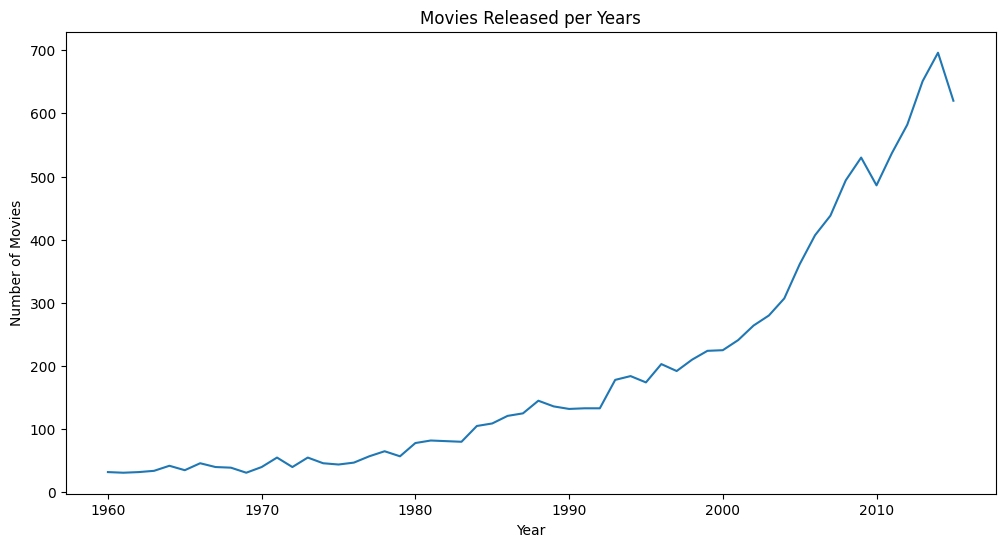

In [40]:
# plot movies released by year
plt.figure(figsize=(12, 6))
plt.plot(release_per_year)
plt.title('Movies Released per Years')
plt.xlabel('Year')
plt.ylabel('Number of Movies')

it clear that the number of Movies Released per Years incerase every year,expet for some years took a smal dip.

# **Research Question 2 (Average runtime of movies by year?)**

In [41]:
# Convert runtime to numeric (this fixes the error)
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
# count movie runtime per year
min_runtime_per_year = df.groupby('release_year').min()['runtime']
max_runtime_per_year = df.groupby('release_year').max()['runtime']
mean_runtime_per_year = df.groupby('release_year')['runtime'].mean()

In [42]:
#second way to write the code
# Method B: Combined (recommended)
runtime_stats = df.groupby('release_year')['runtime'].agg(['min', 'max', 'mean'])

In [43]:
# Method C: Full statistics
runtime_stats = df.groupby('release_year')['runtime'].describe()

In [44]:
runtime_stats.head(5)

,count,mean,std,min,25%,50%,75%,max
release_year,,,,,,,,
1960,32.0,110.656250,33.492040,70.0,85.75,103.5,126.25,208.0
1961,31.0,119.419355,28.168273,79.0,99.00,110.0,135.00,186.0
1962,32.0,124.343750,36.306588,78.0,97.00,117.5,145.00,216.0
1963,34.0,111.323529,37.168511,18.0,89.00,108.5,125.00,248.0
1964,42.0,109.214286,26.230252,28.0,93.00,110.5,124.50,170.0


Let's plot the data for minimum, maximum and mean runtime in different years to see if anything noticable happened.

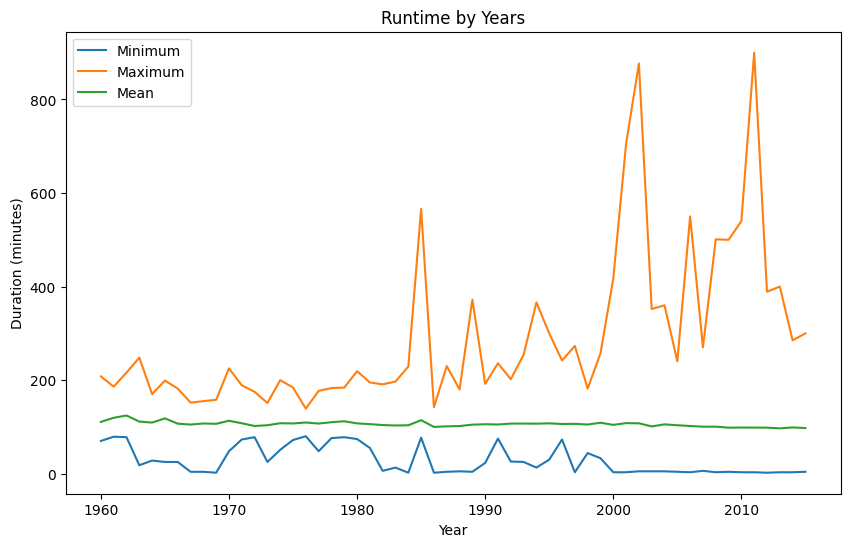

In [45]:
def plot_runtime_by_years(min_runtime_per_year, max_runtime_per_year, mean_runtime_per_year):
    # build the index location for x-axis
    min_index = min_runtime_per_year.index
    max_index = max_runtime_per_year.index
    mean_index = mean_runtime_per_year.index
    # set axes for the plot
    x1, y1 = min_index, min_runtime_per_year
    x2, y2 = max_index, max_runtime_per_year
    x3, y3 = mean_index, mean_runtime_per_year
    # create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(x1, y1, label = 'Minimum')
    plt.plot(x2, y2, label = 'Maximum')
    plt.plot(x3, y3, label = 'Mean')
    # title and labels
    plt.title('Runtime by Years')
    plt.xlabel('Year')
    plt.ylabel('Duration (minutes)');
    plt.legend(loc='upper left')

# Call the function with your data
plot_runtime_by_years(min_runtime_per_year, max_runtime_per_year, mean_runtime_per_year)

We can see that the average duration of movies more or less remains the same. However, there seems to be a contant trend of small films after year 2000. The maximum length of movies also seem to increase overall, and we can see a few very very lengthy movies in later years.

# **Research Question 3 (What makes a successful movie?)**

**Popularity as the measure of success**

in the analysis, I will consider popularity as a measure of success. Higher popularity would mean more success. We will try to answer the following questions:

Does budget makes a movie successful? Does runtime contribute in success of movie? How does success change with year of release? Does user rating play a role in popularity? Role of budget on success (in terms of popularity) Let's see how popularity of movies look like when we take the budget into consideration. I will plot the mean popularity against the budget first.

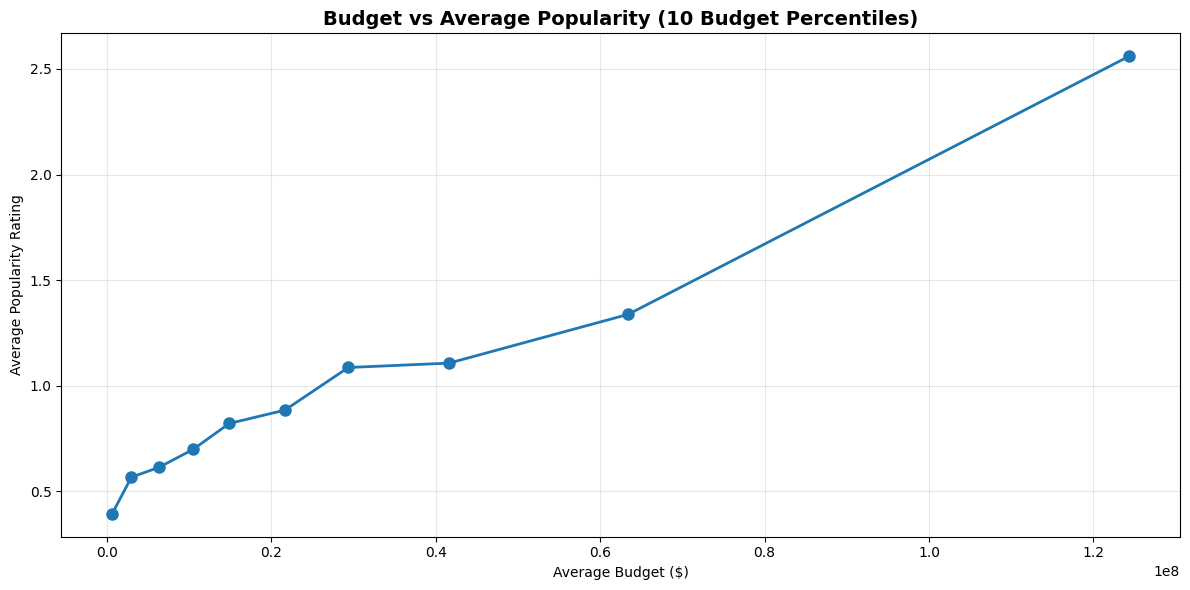

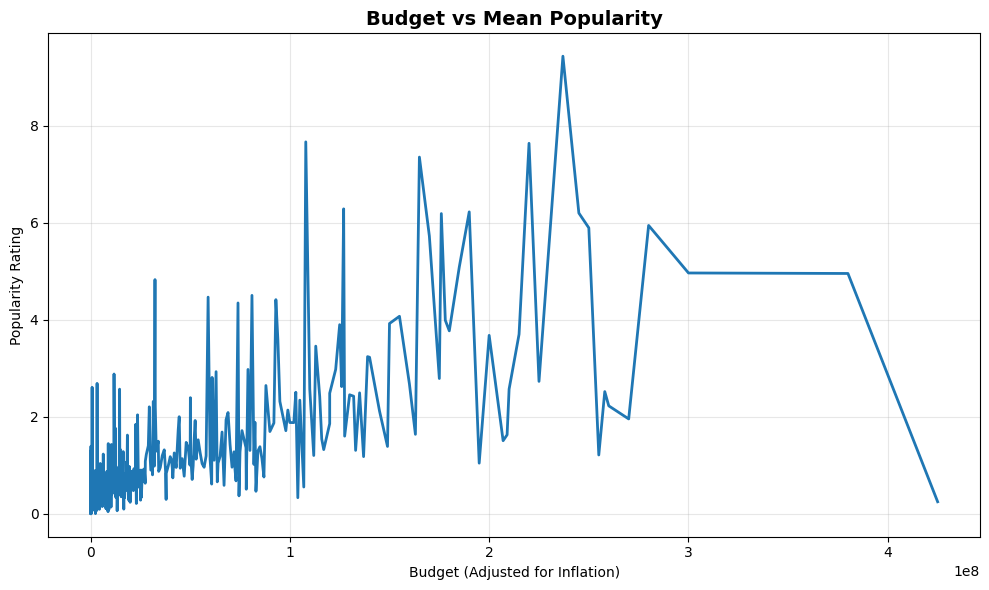

In [46]:
# ============ PLOT 1: Budget Percentiles ============
plt.figure(figsize=(12, 6))

# Fix 1: Add .copy()
df_filtered = df[df['budget'] > 0].copy()

# Create percentiles
df_filtered['budget_percentile'] = pd.qcut(df_filtered['budget'], q=10, labels=False)

# Calculate stats
budget_stats = df_filtered.groupby('budget_percentile').agg({
    'budget': 'mean',
    'popularity': 'mean'
})

# Plot
plt.plot(budget_stats['budget'], budget_stats['popularity'],
         marker='o', linewidth=2, markersize=8)
plt.title('Budget vs Average Popularity (10 Budget Percentiles)',
          fontsize=14, fontweight='bold')
plt.xlabel('Average Budget ($)')
plt.ylabel('Average Popularity Rating')
plt.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============ PLOT 2: Budget vs Mean Popularity ============

# Fix 2: Convert budget to numeric FIRST
df['budget'] = pd.to_numeric(df['budget'], errors='coerce')

plt.figure(figsize=(10, 6))

# Filter out zero/null budgets
df_clean = df[(df['budget'] > 0) & (df['budget'].notna())].copy()

# Group by budget and calculate mean popularity
mean_popularity_grouped_by_budget = df_clean.groupby('budget')['popularity'].mean()

# Plot
plt.plot(mean_popularity_grouped_by_budget.index,
         mean_popularity_grouped_by_budget.values,
         linewidth=2)

# Title and labels
plt.title('Budget vs Mean Popularity', fontsize=14, fontweight='bold')
plt.xlabel('Budget (Adjusted for Inflation)')
plt.ylabel('Popularity Rating')
plt.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

We can see that popularity seems to increase with budget. general trend suggests that higher the budget, higher is popularity. Let's look at the scatter of budget with popularity to gain more insight about this.

**ALTERNATIVE APPROACHES:**
**Method 1: Using Budget Bins (Simpler)**

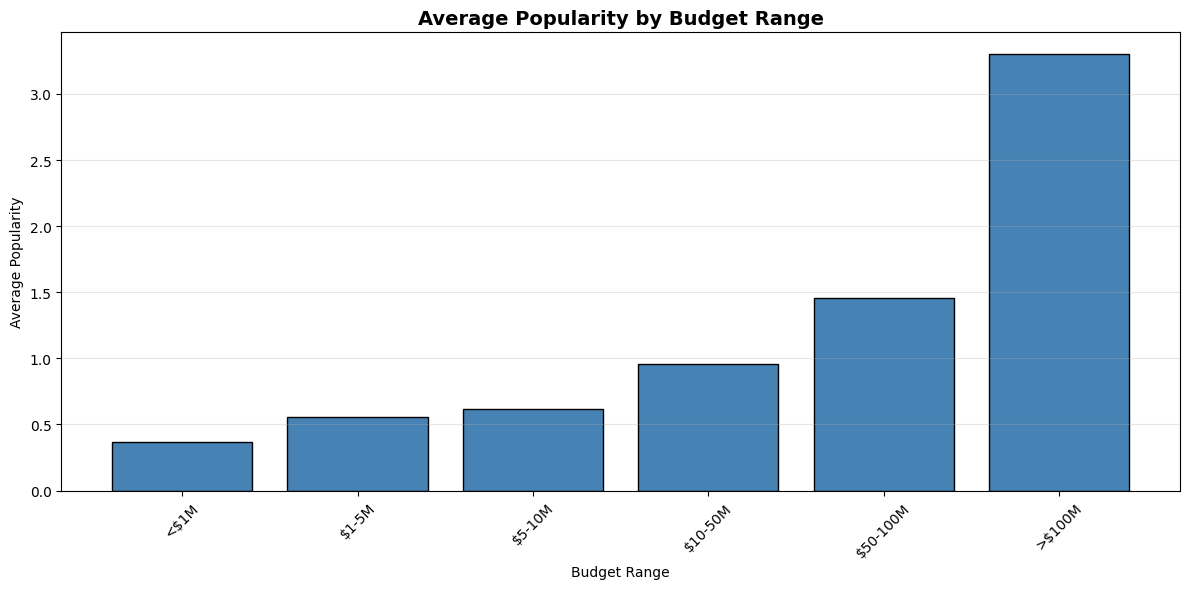

In [47]:
# Create clean budget categories
df_filtered = df[df['budget'] > 0].copy()

# Define budget ranges
bins = [0, 1e6, 5e6, 10e6, 50e6, 100e6, 500e6]
labels = ['<$1M', '$1-5M', '$5-10M', '$10-50M', '$50-100M', '>$100M']

df_filtered['budget_category'] = pd.cut(df_filtered['budget'], bins=bins, labels=labels)

# Calculate average popularity per category
budget_stats = df_filtered.groupby('budget_category', observed=True).agg({
    'budget': 'mean',
    'popularity': 'mean'
})

# Plot
plt.figure(figsize=(12, 6))
plt.bar(budget_stats.index, budget_stats['popularity'], color='steelblue', edgecolor='black')
plt.title('Average Popularity by Budget Range', fontsize=14, fontweight='bold')
plt.xlabel('Budget Range')
plt.ylabel('Average Popularity')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Method 2: Scatter Plot with Trend Line**

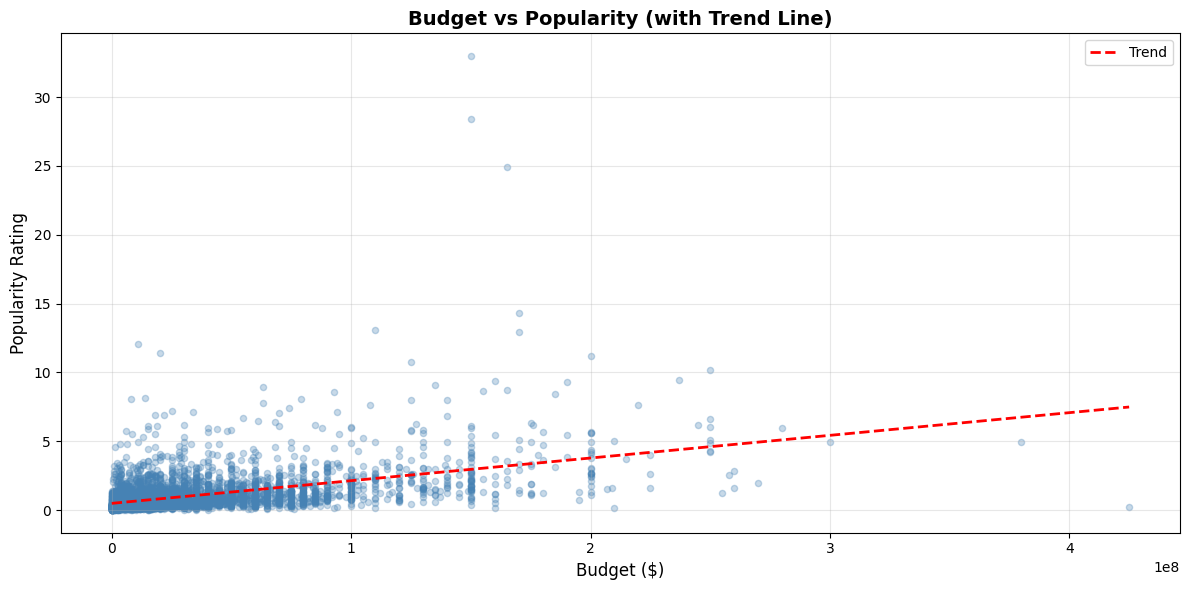

Correlation: 0.480


In [48]:
# Filter data
df_filtered = df[(df['budget'] > 0) & (df['popularity'] > 0)].copy()

# Sample if too many points
sample_size = min(5000, len(df_filtered))
df_sample = df_filtered.sample(n=sample_size, random_state=42)

# Scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(df_sample['budget'], df_sample['popularity'],
           alpha=0.3, s=20, color='steelblue')

# Add trend line
z = np.polyfit(df_sample['budget'], df_sample['popularity'], 1)
p = np.poly1d(z)
plt.plot(df_sample['budget'].sort_values(),
         p(df_sample['budget'].sort_values()),
         "r--", linewidth=2, label='Trend')

plt.title('Budget vs Popularity (with Trend Line)', fontsize=14, fontweight='bold')
plt.xlabel('Budget ($)', fontsize=12)
plt.ylabel('Popularity Rating', fontsize=12)
plt.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = df_filtered['budget'].corr(df_filtered['popularity'])
print(f"Correlation: {correlation:.3f}")

From the above scatter plot, we can see that as the budget increases, the movies seem to be slightly more popular, but this is not a definitive trend. Some of the most popular movies lie in the middle of our budget scale. We can see that we have popular movies at all types of budget. But most of the lower budget movies seem to be less popular. The dip in the mean popularity is explained by the low popularity and low movie count in high budget.

##So budget of a movie might not be a direct factor in success, but movies having a higher budget seems to be popular

It doesn't however mean that higher budget makes a movie popular.

**Method 3: Box Plot by Budget Ranges**

/tmp/ipykernel_439/2479725774.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='budget_category', y='popularity',


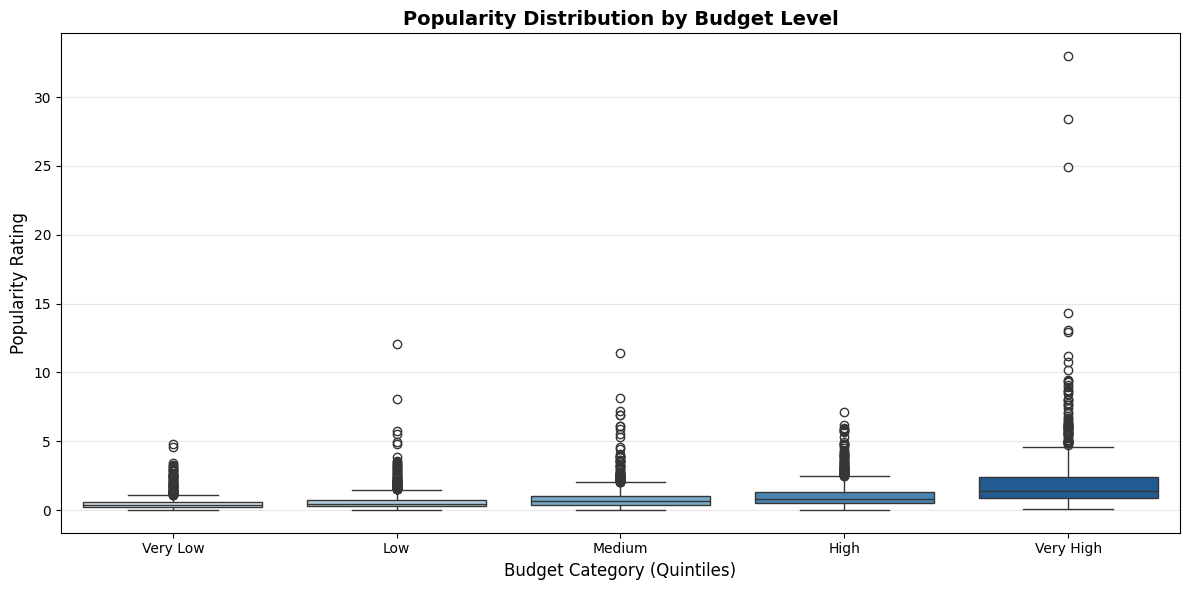

In [49]:
# Filter and create categories
df_filtered = df[df['budget'] > 0].copy()
df_filtered['budget_category'] = pd.qcut(df_filtered['budget'], q=5,
                                         labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# Box plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_filtered, x='budget_category', y='popularity',
           palette='Blues')

plt.title('Popularity Distribution by Budget Level', fontsize=14, fontweight='bold')
plt.xlabel('Budget Category (Quintiles)', fontsize=12)
plt.ylabel('Popularity Rating', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

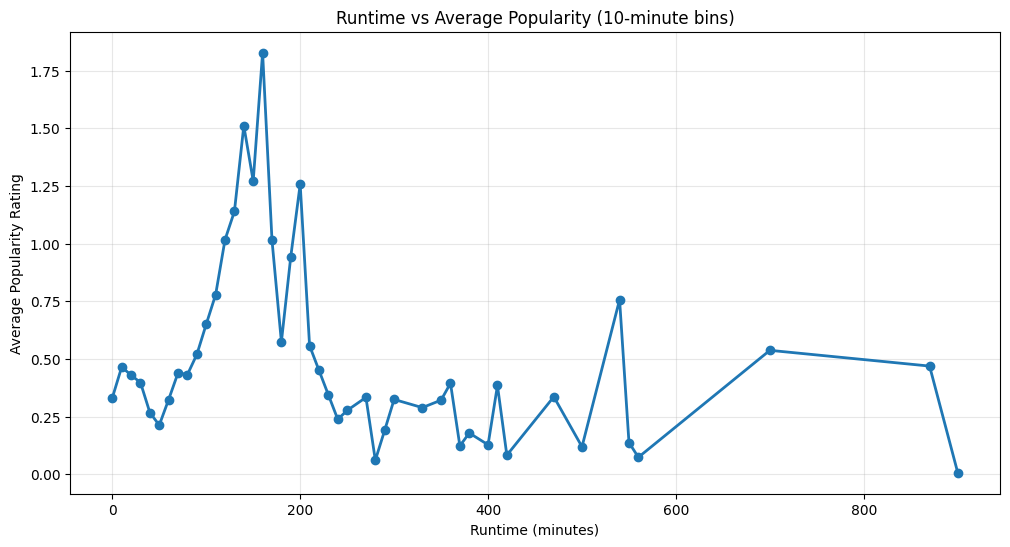

In [50]:
##Role of runtime on success
# plot runtime vs average Popularity

plt.figure(figsize=(12, 6))
df['runtime_bins'] = (df['runtime'] // 10) * 10  # Round to nearest 10 minutes
runtime_avg = df.groupby('runtime_bins')['popularity'].mean()

plt.plot(runtime_avg.index, runtime_avg.values, marker='o', linewidth=2, markersize=6)
# title and labels
plt.title('Runtime vs Average Popularity (10-minute bins)')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Average Popularity Rating')
plt.grid(True, alpha=0.3)
plt.show()

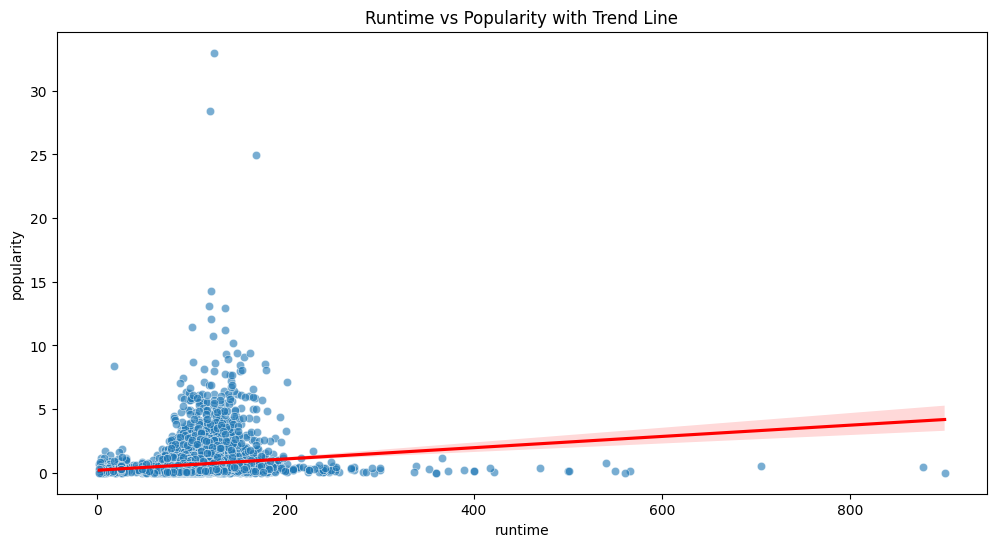

In [51]:
# plot runtime vs popularity
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='runtime', y='popularity', alpha=0.6)
sns.regplot(data=df, x='runtime', y='popularity', scatter=False, color='red')
plt.title('Runtime vs Popularity with Trend Line')
plt.show()

# **# Movies which are around 120 to 140 minutes long seem to be more popular with audience.**
**Most popular movies have time around 120 minutes. However movies around 150-170 minutes have more popularity in terms of average.**

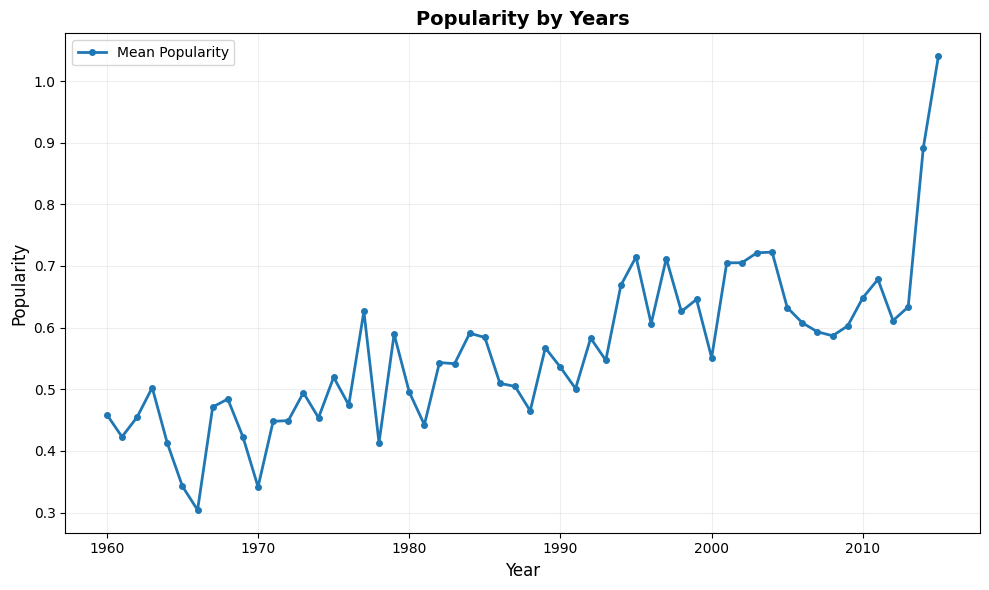

In [63]:
# Plot mean popularity vs year
mean_popularity_grouped_by_year = df.groupby('release_year')['popularity'].mean()
#

# Set axes for the plot
x1 = mean_popularity_grouped_by_year.index
y1 = mean_popularity_grouped_by_year.values

plt.figure(figsize=(10, 6))
plt.plot(x1, y1, label='Mean Popularity', linewidth=2, marker='o', markersize=4)

# Title and labels
plt.title('Popularity by Years', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Popularity', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Popularity seems to be moving upwards as the years progress. This seems correct as the newer movies are more easily dicovered and hence they will be more popular. Since mean values measure more of a central tendency, let's look at the absolute values in a scatter plot.

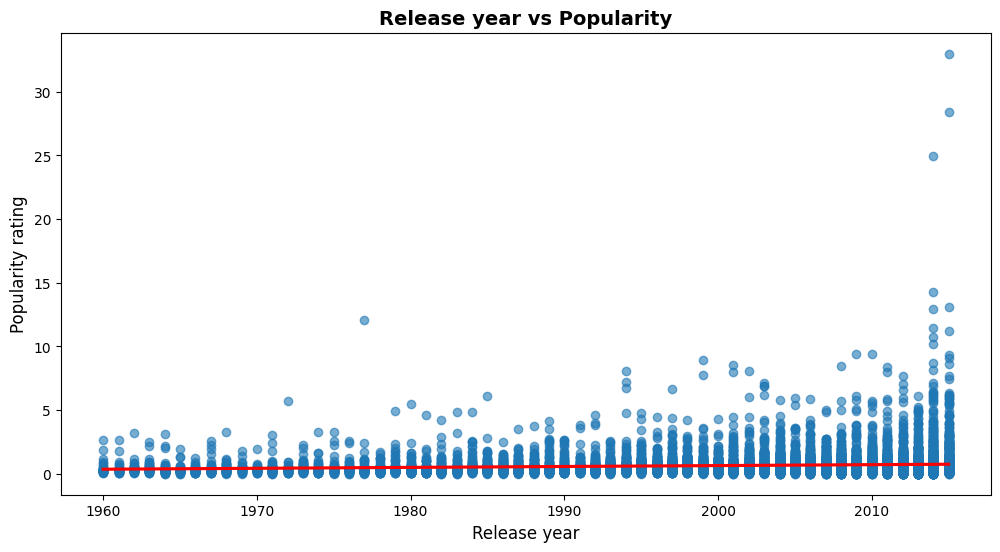

In [57]:
# plot release year vs popularity
plt.figure(figsize=(12, 6))
sns.regplot(data=df, x='release_year', y='popularity', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
# title and labels
plt.title('Release year vs Popularity',fontsize=14, fontweight='bold')
plt.xlabel('Release year',fontsize=12)
plt.ylabel('Popularity rating',fontsize=12);


We can see that most movies over the years are not very popular, btu there is a definite rise in popular movies over the years.

Movies which are releases in recent past seem to be more popular. So there is a good chance of success for newly released movies

Given the fact that a lot of new movies are still densly located at low popularity rankings, release year does not ensure success as it might seem from the mean plot above.

# **Role of user rating on success:**
Let's see how popularity is affected by user ratings. However both of these seem to be the same thing, let's see if there is a relation between both. We will have two trends plotted, one where we take number of user ratings in account, and other where we take the average user rating. Again we will consider mean popularity and then look at the distribution in scatter plots.

/tmp/ipykernel_439/3051804147.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


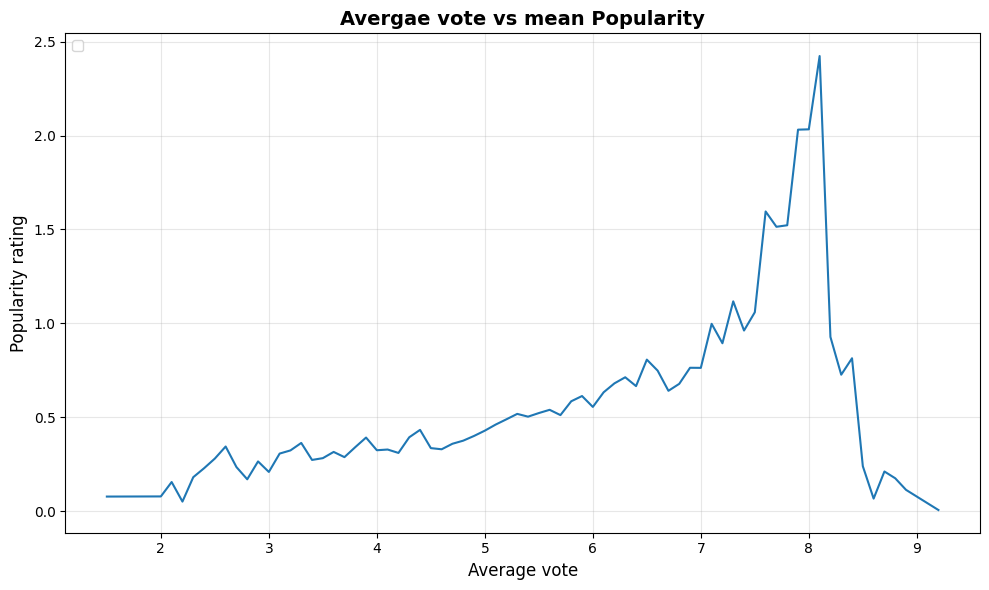

In [60]:
# plot average vote vs average Popularity
plt.figure(figsize=(10, 6))
mean_popularity_grouped_by_vote_average = df.groupby('vote_average')['popularity'].mean()

plt.plot(mean_popularity_grouped_by_vote_average.index, mean_popularity_grouped_by_vote_average)

# title and labels
plt.title('Avergae vote vs mean Popularity',fontsize=14,fontweight='bold')
plt.xlabel('Average vote',fontsize=12)
plt.ylabel('Popularity rating',fontsize=12);
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

We can see that on an average, movies with higher vote average are more popular. Again we see a dip in the popularity at the extreme of average vote where a highly voted movie is not very popular. But the general trend suggests that better the vote average, more the popularity and hence movie is a success. Now let's look at the distribution of vote average with popularity in a scatter plot.

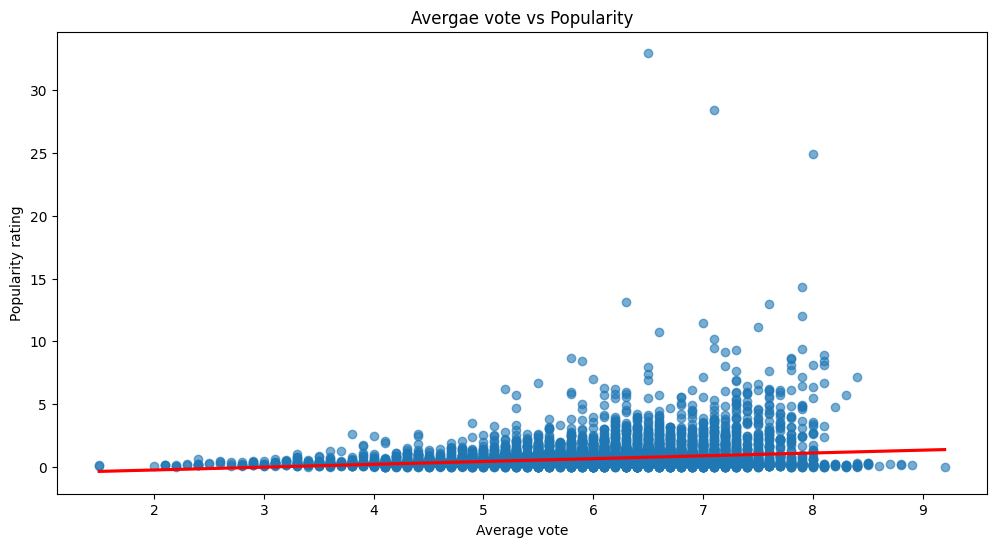

In [64]:
# plot vote average vs popularity
plt.figure(figsize=(12, 6))
sns.regplot(data=df, x='vote_average', y='popularity', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
# title and labels
plt.title('Avergae vote vs Popularity')
plt.xlabel('Average vote')
plt.ylabel('Popularity rating');

While movies with high average votes seem to be more popular, there is still a chance that high vote average movie might not be popular. But low votes definetly show that movie won't be popular

Now lets look how number of votes casted fare with popularity of movie. We will look at the mean popularity first and then have a look at the scatter plot to further analyze

Text(0, 0.5, 'Popularity rating')

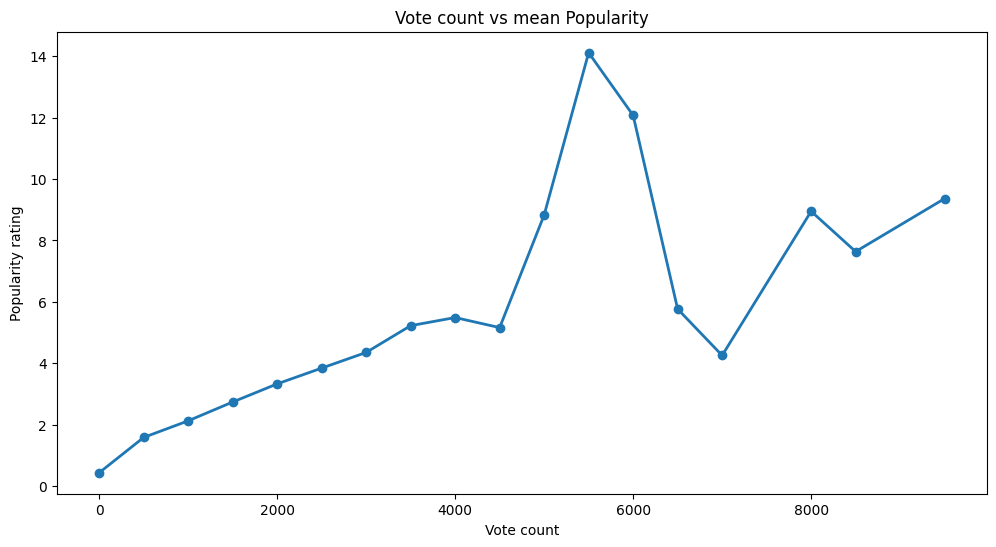

In [65]:
# plot vote count vs average Popularity

#
plt.figure(figsize=(12, 6))
df['vote_count_bins'] = (df['vote_count'] // 500) * 500
vote_avg = df.groupby('vote_count_bins')['popularity'].mean()
plt.plot(vote_avg.index, vote_avg.values, marker='o', linewidth=2)
plt.title('Vote count vs mean Popularity')
plt.xlabel('Vote count')
plt.ylabel('Popularity rating')

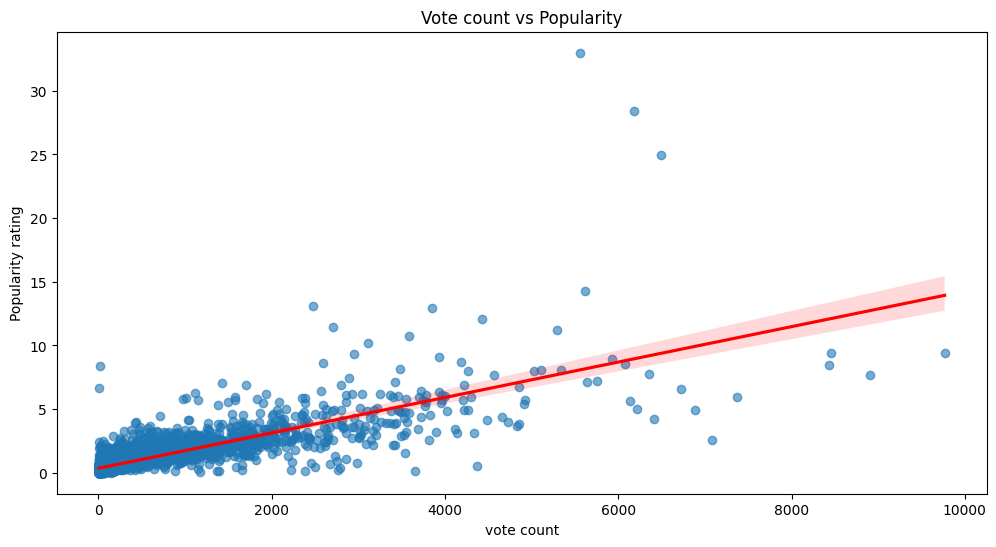

In [66]:
# plot vote count vs popularity
plt.figure(figsize=(12, 6))
sns.regplot(data=df, x='vote_count', y='popularity', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
# title and labels
plt.title('Vote count vs Popularity')
plt.xlabel('vote count')
plt.ylabel('Popularity rating');

We can see in the graph that popularity increases as the number of votes increase. This makes sense as more the number of people watching it, more people will vote and more popular the movie will be.

More the numbers of vote casted, more popular the movie is. This loop kind of feeds itself as more votes means more popular and then more people watch it and more will vote.

# **Conclusions**
My research shows that the number of movies released each year has been steadily increasing, with a particularly sharp surge after the year 2000.

The study also demonstrates that, while the average runtime of movies has remained relatively stable over time, recent years reveal greater variation. We now see a rising presence of short films alongside a smaller number of very long productions.

Furthermore, the analysis highlights several factors that contribute to a movie’s success, where success is defined as popularity. Popular movies tend to have higher budgets, runtimes in the range of 120–140 minutes, recent release years, and attract stronger audience engagement through higher vote counts and higher vote averages. In particular, vote count and vote average stand out as key indicators of popularity, while newer releases are generally more successful than older ones.

# **Limitations of the Study**
The findings of this study are constrained by the quality of the available data. During the data wrangling phase, a significant number of missing values were observed, particularly for budget and revenue, which limits the reliability of conclusions related to these variables.

While the results clearly highlight trends in the number of movies released per year and the stability of movie runtimes, the analysis of factors contributing to a movie’s success should be interpreted with caution. The study identifies characteristics that are commonly found in successful movies, but this does not necessarily imply causation. In other words, while high budgets, vote counts, and vote averages are often associated with popular films, they may not be the underlying reasons for a movie’s success.

In [67]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

[NbConvertApp] WARNING | pattern 'Investigate_a_Dataset.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--e